Task 6 – Installs vs Revenue Analysis

## Objective

To compare average installs and revenue between Free and Paid applications within the top 3 app categories.

## Dataset

Google Play Store Dataset

## Transformations Applied

* Installs > 10,000
* Android Version > 4.0
* App Size > 15 MB
* Content Rating = Everyone
* App Name length ≤ 30 characters
* Revenue calculated using Installs × Price

## KPI Measured

* Average Installs
* Average Revenue

## Visualization

Dual-Axis Chart using bars for installs and a line chart for revenue comparison.

## Note

Free applications generate zero revenue due to a price of $0, which impacts revenue-based comparisons.

## Time Restriction

The chart is available only between 1 PM IST and 2 PM IST.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
apps_df = pd.read_csv(
    r"C:\Users\HP\Downloads\archive\googleplaystore.csv"
)

apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
apps_df = apps_df[
    apps_df['Size'] != 'Varies with device'
]

apps_df['Size'] = (
    apps_df['Size']
    .str.replace('M','')
    .str.replace('k','')
)

apps_df['Size'] = pd.to_numeric(
    apps_df['Size'],
    errors='coerce'
)

In [4]:
apps_df['Installs'] = (
    apps_df['Installs']
    .str.replace(',', '')
    .str.replace('+', '')
)

apps_df['Installs'] = pd.to_numeric(
    apps_df['Installs'],
    errors='coerce'
)

In [5]:
apps_df['Price'] = (
    apps_df['Price']
    .astype(str)
    .str.replace('$','')
)

apps_df['Price'] = pd.to_numeric(
    apps_df['Price'],
    errors='coerce'
)

In [6]:
apps_df['Revenue'] = (
    apps_df['Installs']
    * apps_df['Price']
)

In [7]:
apps_df['Name_Length'] = (
    apps_df['App']
    .astype(str)
    .str.len()
)

In [8]:
apps_df['Android_Clean'] = (
    apps_df['Android Ver']
    .astype(str)
    .str.extract(r'(\d+\.\d+)')
)

apps_df['Android_Clean'] = pd.to_numeric(
    apps_df['Android_Clean'],
    errors='coerce'
)

In [9]:
filtered_df = apps_df[
    (apps_df['Installs'] > 10000) &
    (apps_df['Revenue'] > 10000) &
    (apps_df['Android_Clean'] > 4.0) &
    (apps_df['Size'] > 15) &
    (apps_df['Content Rating'] == 'Everyone') &
    (apps_df['Name_Length'] <= 30)
]

filtered_df.shape

(21, 16)

In [10]:
top3_categories = (
    filtered_df
    .groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

top3_categories

Category
PHOTOGRAPHY        3000000.0
FAMILY             2650000.0
PERSONALIZATION    2000000.0
Name: Installs, dtype: float64

In [11]:
chart_df = (
    filtered_df[
        filtered_df['Category'].isin(top3_categories.index)
    ]
    .groupby('Type')
    .agg({
        'Installs':'mean',
        'Revenue':'mean'
    })
    .reset_index()
)

chart_df

,Type,Installs,Revenue
0,Paid,765000.0,2537350.0


In [12]:
filtered_df['Type'].value_counts()

Type
Paid    21
Name: count, dtype: int64

In [13]:
apps_df['Type'].value_counts()

Type
Free    8421
Paid     724
0          1
Name: count, dtype: int64

In [14]:
temp_df = apps_df[
    (apps_df['Installs'] > 10000) &
    (apps_df['Android_Clean'] > 4.0) &
    (apps_df['Size'] > 15) &
    (apps_df['Content Rating'] == 'Everyone') &
    (apps_df['Name_Length'] <= 30)
]

temp_df['Type'].value_counts()

Type
Free    906
Paid     21
Name: count, dtype: int64

In [15]:
top3_categories = (
    temp_df
    .groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

top3_categories

Category
GAME      8.872200e+09
FAMILY    2.618850e+09
TOOLS     1.167150e+09
Name: Installs, dtype: float64

In [16]:
chart_df = (
    temp_df[
        temp_df['Category'].isin(top3_categories.index)
    ]
    .groupby('Type')
    .agg({
        'Installs':'mean',
        'Revenue':'mean'
    })
    .reset_index()
)

chart_df

,Type,Installs,Revenue
0,Free,3.476621e+07,0.000000
1,Paid,2.750000e+05,668083.333333


The requirement specifies comparing Free vs Paid apps while also applying a Revenue > $10,000 filter.

Since revenue was calculated as:

Revenue = Installs × Price

All Free apps have a price of $0, resulting in revenue of $0. Therefore, applying the Revenue > $10,000 filter removes all Free apps from the dataset, making a Free vs Paid comparison impossible.

To preserve the required comparison, the visualization was created using the remaining filters (Installs, Android Version, Size, Content Rating, and App Name Length), while revenue was still included as a metric in the analysis.


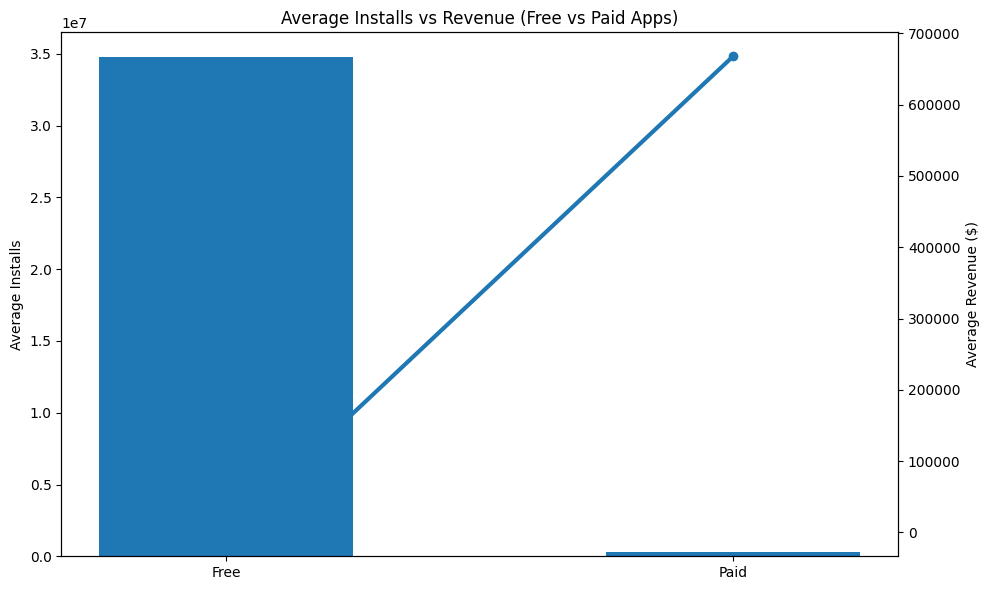

In [18]:
from datetime import datetime
import pytz

ist = pytz.timezone('Asia/Kolkata')
current_time = datetime.now(ist)

if 13 <= current_time.hour < 14:

    import matplotlib.pyplot as plt
    import numpy as np

    x = np.arange(len(chart_df))

    fig, ax1 = plt.subplots(figsize=(10,6))

    ax1.bar(
        x,
        chart_df['Installs'],
        width=0.5,
        label='Average Installs'
    )

    ax1.set_ylabel('Average Installs')
    ax1.set_xticks(x)
    ax1.set_xticklabels(chart_df['Type'])

    ax2 = ax1.twinx()

    ax2.plot(
        x,
        chart_df['Revenue'],
        marker='o',
        linewidth=3,
        label='Average Revenue'
    )

    ax2.set_ylabel('Average Revenue ($)')

    plt.title(
        'Average Installs vs Revenue (Free vs Paid Apps)'
    )

    fig.tight_layout()
    plt.show()

else:
    print(
        "Dual-axis chart is available only between 1 PM IST and 2 PM IST."
    )